# Análisis Exploratorio de Datos (EDA)

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(janitor)
  library(gt)
})

repr_html.gt_tbl <- function(obj, ...) gt::as_raw_html(obj)
repr_markdown.gt_tbl <- function(obj, ...) NULL
repr_latex.gt_tbl <- function(obj, ...) NULL
for (g in c("repr_html", "repr_markdown", "repr_latex")) {
  registerS3method(g, "gt_tbl", get(paste0(g, ".gt_tbl")), envir = asNamespace("repr"))
}

theme_set(theme_minimal(base_size = 12))

bar_fill <- viridisLite::viridis(6)[4]

## Carga de datos

In [2]:
readRenviron("../.Renviron")
DATA_PATH <- file.path("..", Sys.getenv("DATA_PATH", unset = "data/df_moderation_2026.csv"))

df <- read_csv(DATA_PATH, show_col_types = FALSE)

glimpse(df)

Rows: 680
Columns: 12
$ Gender        <chr> "Female", "Female", "Female", "Female", "Female", "Femal…
$ Age           <dbl> 15, 15, 15, 15, 17, 15, 17, 15, 17, 15, 15, 15, 16, 16, …
$ Ethnicity     <chr> "Afrodescendant", "Mestizo", "Mestizo", NA, "Afrodescend…
$ Grade         <dbl> 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, …
$ SSE           <chr> "Low", NA, NA, NA, "Low", "Low", "Low", "Low", "Low", "L…
$ Education     <chr> "High School", "High School", "High School", "High Schoo…
$ Municipality  <chr> "Polo Nuevo", "Polo Nuevo", "Polo Nuevo", "Polo Nuevo", …
$ Family        <dbl> -1.52555119, 0.47260174, 0.65589211, -1.08496449, 0.9546…
$ Friends       <dbl> -1.4278704, 0.3525064, 0.3169250, -0.7116390, 1.2053372,…
$ SigOthers     <dbl> -1.0856793, 0.3935668, 0.3133314, -0.7474170, 0.8657182,…
$ Entrapment    <dbl> 1.03400222, -0.85269867, -0.85269867, -0.54487932, -0.22…
$ Entrapment_SE <dbl> 0.3209509, 0.4673559, 0.4673559, 0.3491078, 0.3074096, 0…


## Datos faltantes por variable

Antes de examinar cada variable individualmente, se resume la proporción de
valores faltantes por columna sobre el total de la muestra (N = 680).

In [3]:
missing_summary <- df %>%
  summarise(across(everything(), ~ sum(is.na(.) | . == ""))) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "n_missing") %>%
  mutate(pct_missing = round(100 * n_missing / nrow(df), 2)) %>%
  arrange(desc(n_missing))

missing_summary %>%
  gt() %>%
  tab_header(title = "Datos faltantes por variable")

<div id="ulhlsmfoqx" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#ulhlsmfoqx table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#ulhlsmfoqx thead, #ulhlsmfoqx tbody, #ulhlsmfoqx tfoot, #ulhlsmfoqx tr, #ulhlsmfoqx td, #ulhlsmfoqx th {
  border-style: none;
}

#ulhlsmfoqx p {
  margin: 0;
  padding: 0;
}

#ulhlsmfoqx .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#ulhlsmfoqx .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#ulhlsmfoqx .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#ulhlsmfoqx .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#ulhlsmfoqx .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#ulhlsmfoqx .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#ulhlsmfoqx .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#ulhlsmfoqx .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#ulhlsmfoqx .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#ulhlsmfoqx .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#ulhlsmfoqx .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#ulhlsmfoqx .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#ulhlsmfoqx .gt_spanner_row {
  border-bottom-style: hidden;
}

#ulhlsmfoqx .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

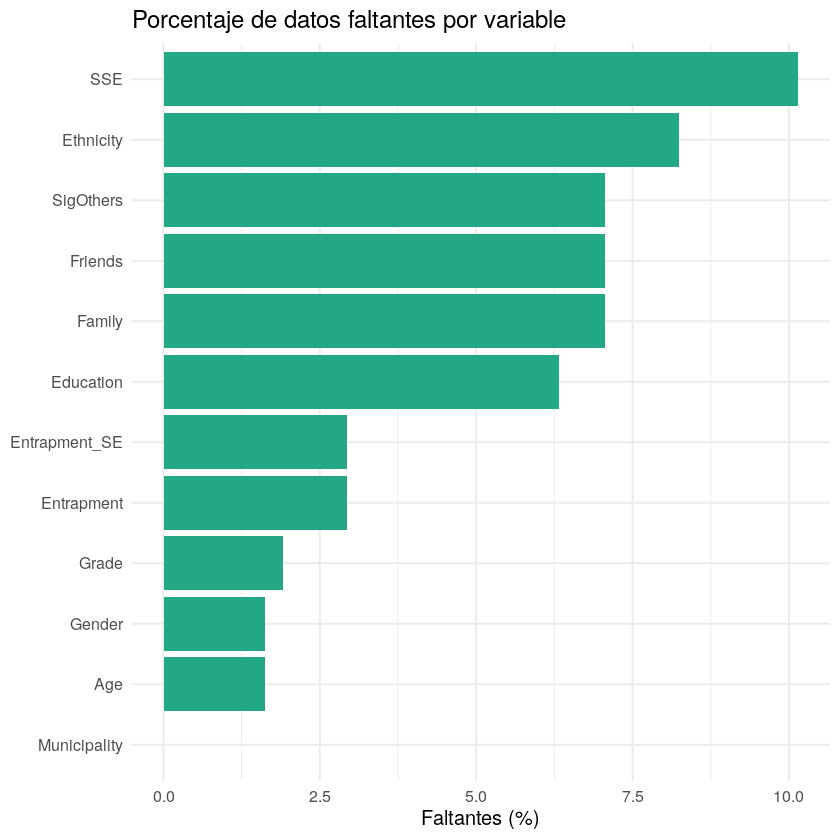

In [4]:
ggplot(missing_summary, aes(x = fct_reorder(Variable, pct_missing), y = pct_missing)) +
  geom_col(fill = bar_fill) +
  coord_flip() +
  labs(title = "Porcentaje de datos faltantes por variable",
       x = NULL, y = "Faltantes (%)")

## Función auxiliar de frecuencias

Se define una función auxiliar para reproducir, de forma consistente, las
tablas de frecuencia y los gráficos de barras (conteo + porcentaje) usados en
el EDA original para las covariables categóricas.

In [5]:
freq_table <- function(data, var, levels_order = NULL) {
  x <- data[[var]]
  x_chr <- as.character(x)
  x_chr[is.na(x_chr) | x_chr == ""] <- "Missing"

  if (is.null(levels_order)) {
    lv <- c(sort(unique(x_chr[x_chr != "Missing"])), "Missing")
  } else {
    lv <- c(levels_order, "Missing")
  }

  tibble(Category = factor(x_chr, levels = lv)) %>%
    count(Category, .drop = FALSE, name = "n") %>%
    mutate(pct = round(100 * n / sum(n), 2))
}

plot_freq <- function(tbl, title, xlab) {
  ggplot(tbl, aes(x = Category, y = pct)) +
    geom_col(fill = bar_fill) +
    geom_text(aes(label = n), vjust = -0.4, fontface = "bold") +
    scale_y_continuous(limits = c(0, 100)) +
    labs(title = title, x = xlab, y = "Participantes (%)")
}

## Género

Distribución de la muestra por género (`Female`, `Male`), con los casos sin
respuesta agrupados como `Missing`.

In [6]:
gender_tbl <- freq_table(df, "Gender", levels_order = c("Female", "Male"))
gender_tbl %>% gt() %>% tab_header(title = "Género")

<div id="kubeeccxkt" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#kubeeccxkt table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#kubeeccxkt thead, #kubeeccxkt tbody, #kubeeccxkt tfoot, #kubeeccxkt tr, #kubeeccxkt td, #kubeeccxkt th {
  border-style: none;
}

#kubeeccxkt p {
  margin: 0;
  padding: 0;
}

#kubeeccxkt .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#kubeeccxkt .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#kubeeccxkt .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#kubeeccxkt .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#kubeeccxkt .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#kubeeccxkt .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#kubeeccxkt .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#kubeeccxkt .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#kubeeccxkt .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#kubeeccxkt .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#kubeeccxkt .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#kubeeccxkt .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#kubeeccxkt .gt_spanner_row {
  border-bottom-style: hidden;
}

#kubeeccxkt .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

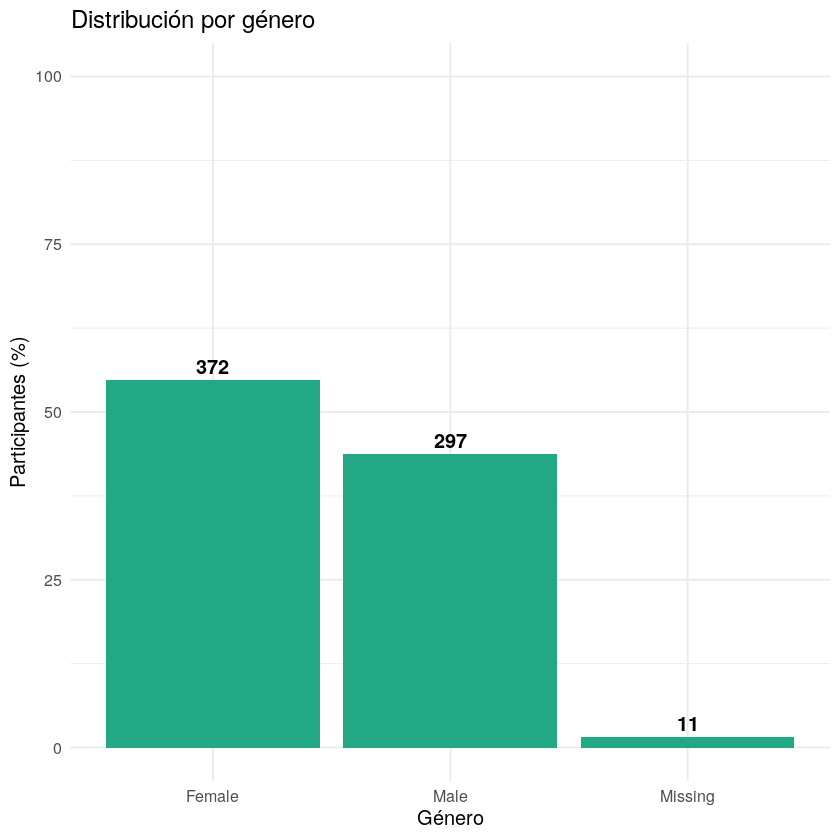

In [7]:
plot_freq(gender_tbl, "Distribución por género", "Género")

## Edad

`Age` fue recolectada como campo numérico abierto. Se examina la
completitud, la distribución (histograma y boxplot) y la presencia de
valores atípicos mediante un filtro de Hampel
($\text{mediana} \pm 3 \times \text{MAD}$), consistente con el criterio
usado en el EDA original.

In [8]:
hampel_bounds <- function(x, k = 3) {
  x <- x[!is.na(x)]
  med <- median(x)
  mad_x <- mad(x, constant = 1.4826)
  c(lower = med - k * mad_x, upper = med + k * mad_x)
}

age_complete <- sum(!is.na(df$Age))
age_missing <- sum(is.na(df$Age))

cat(sprintf("Edad: %d completos, %d faltantes (%.2f%%)\n",
            age_complete, age_missing, 100 * age_missing / nrow(df)))

summary(df$Age)

Edad: 669 completos, 11 faltantes (1.62%)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  13.00   15.00   16.00   15.95   17.00   20.00      11 

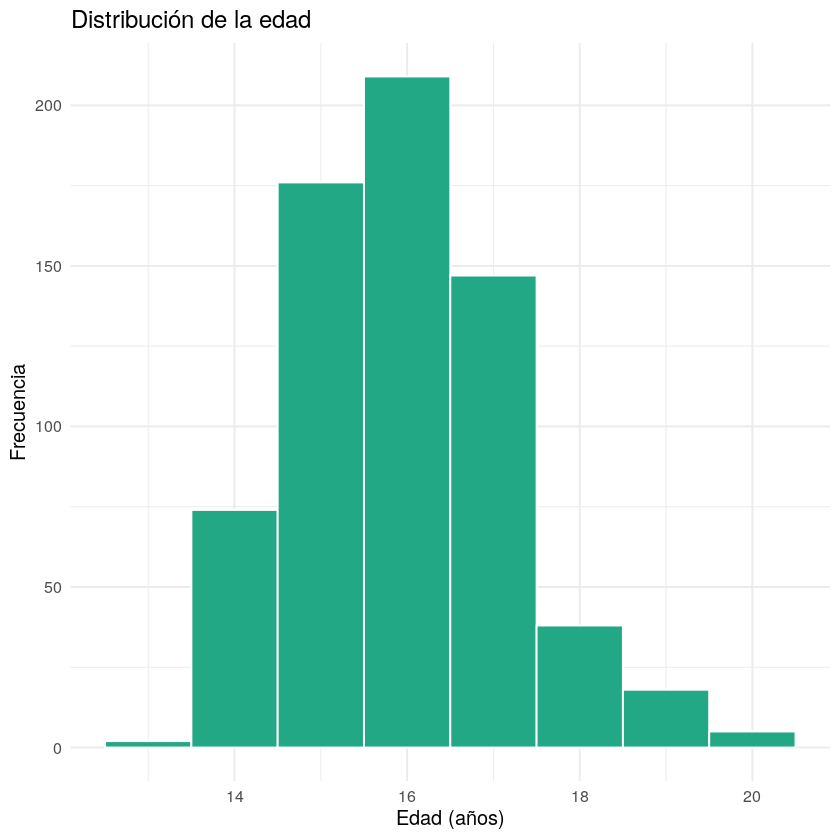

In [9]:
ggplot(df, aes(x = Age)) +
  geom_histogram(binwidth = 1, fill = bar_fill, color = "white", na.rm = TRUE) +
  labs(title = "Distribución de la edad", x = "Edad (años)", y = "Frecuencia")

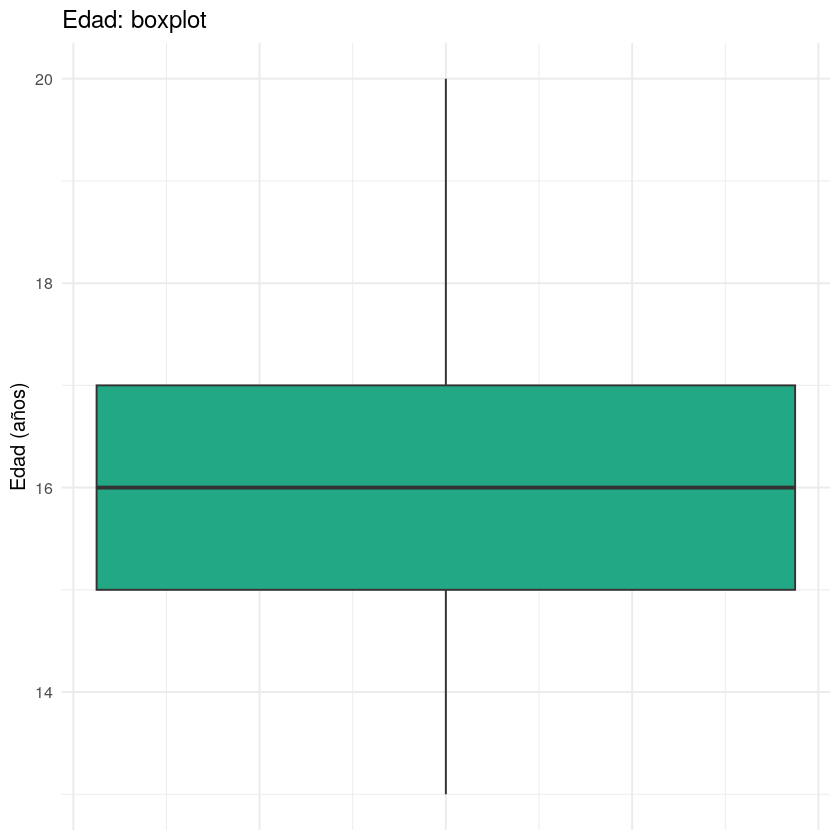

In [10]:
ggplot(df, aes(y = Age)) +
  geom_boxplot(fill = bar_fill, na.rm = TRUE) +
  labs(title = "Edad: boxplot", y = "Edad (años)", x = NULL) +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

In [11]:
age_bounds <- hampel_bounds(df$Age)
age_bounds

age_outliers <- df %>% filter(Age < age_bounds["lower"] | Age > age_bounds["upper"])
nrow(age_outliers)

lower   upper 
11.5522 20.4478

[1] 0

## Grado escolar

`Grade` fue estandarizado a los tres niveles de la cohorte: 9.º, 10.º y
11.º grado.

In [12]:
df <- df %>% mutate(Grade = as.character(Grade))

grade_tbl <- freq_table(df, "Grade", levels_order = c("9", "10", "11"))
grade_tbl %>% gt() %>% tab_header(title = "Grado escolar")

<div id="ceoaphittn" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#ceoaphittn table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#ceoaphittn thead, #ceoaphittn tbody, #ceoaphittn tfoot, #ceoaphittn tr, #ceoaphittn td, #ceoaphittn th {
  border-style: none;
}

#ceoaphittn p {
  margin: 0;
  padding: 0;
}

#ceoaphittn .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#ceoaphittn .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#ceoaphittn .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#ceoaphittn .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#ceoaphittn .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#ceoaphittn .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#ceoaphittn .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#ceoaphittn .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#ceoaphittn .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#ceoaphittn .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#ceoaphittn .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#ceoaphittn .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#ceoaphittn .gt_spanner_row {
  border-bottom-style: hidden;
}

#ceoaphittn .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

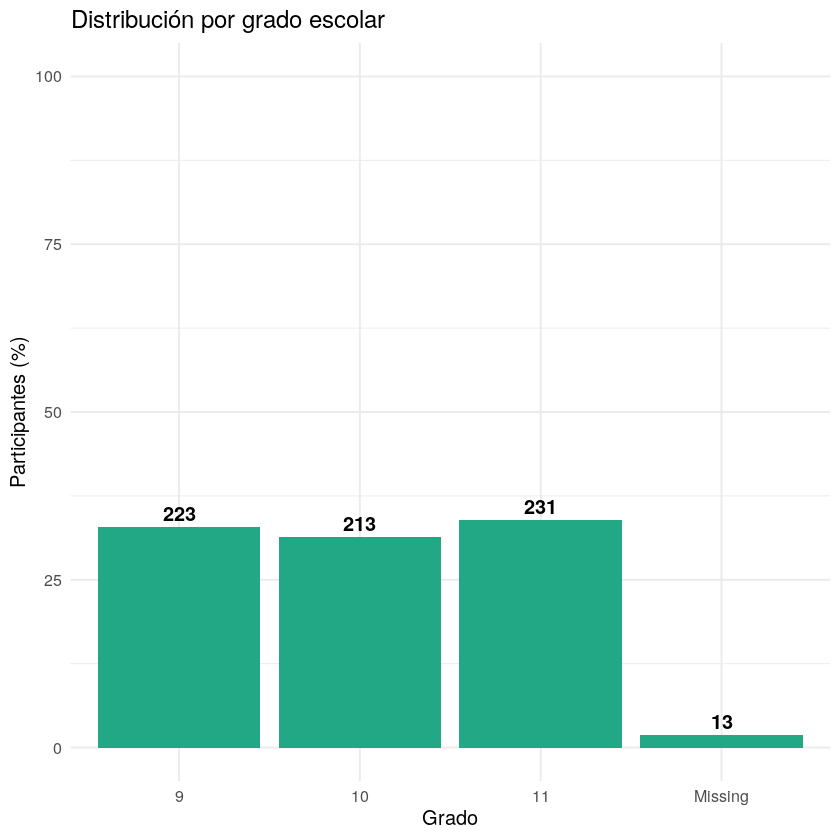

In [13]:
plot_freq(grade_tbl, "Distribución por grado escolar", "Grado")

## Municipio

El indicador institucional original fue reemplazado por la comunidad
geográfica a la que pertenece cada colegio, para evitar déficits de
frecuencia en el análisis por institución.

In [14]:
municip_tbl <- freq_table(df, "Municipality",
                           levels_order = c("Polo Nuevo", "Santo Tomas",
                                             "Puerto Colombia", "Suan"))
municip_tbl %>% gt() %>% tab_header(title = "Municipio")

<div id="tgdqwwpqdk" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#tgdqwwpqdk table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#tgdqwwpqdk thead, #tgdqwwpqdk tbody, #tgdqwwpqdk tfoot, #tgdqwwpqdk tr, #tgdqwwpqdk td, #tgdqwwpqdk th {
  border-style: none;
}

#tgdqwwpqdk p {
  margin: 0;
  padding: 0;
}

#tgdqwwpqdk .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#tgdqwwpqdk .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#tgdqwwpqdk .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#tgdqwwpqdk .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#tgdqwwpqdk .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#tgdqwwpqdk .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#tgdqwwpqdk .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#tgdqwwpqdk .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#tgdqwwpqdk .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#tgdqwwpqdk .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#tgdqwwpqdk .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#tgdqwwpqdk .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#tgdqwwpqdk .gt_spanner_row {
  border-bottom-style: hidden;
}

#tgdqwwpqdk .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

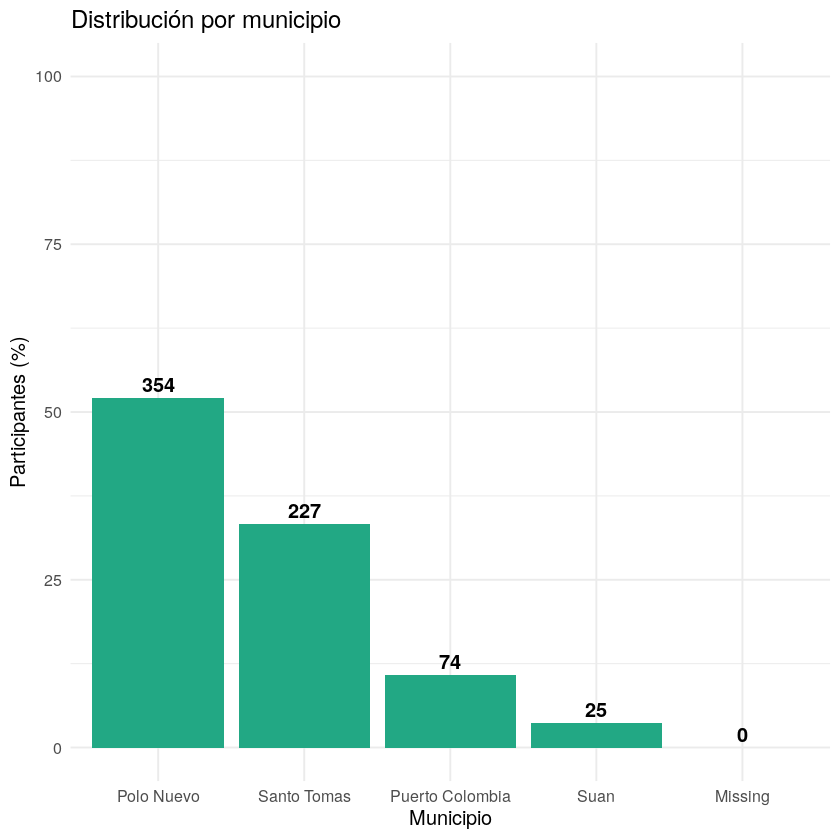

In [15]:
plot_freq(municip_tbl, "Distribución por municipio", "Municipio")

## Etnia

Las categorías de baja frecuencia (Asiático, Indígena, Otro) fueron
consolidadas en un nivel `Other`, preservando la granularidad demográfica de
los tres grupos principales: Mestizo, Caucásico y Afrodescendiente.

In [16]:
ethnicity_tbl <- freq_table(df, "Ethnicity",
                             levels_order = c("Mestizo", "Caucasian",
                                               "Afrodescendant", "Other"))
ethnicity_tbl %>% gt() %>% tab_header(title = "Grupo étnico")

<div id="jxsbbcbzwd" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#jxsbbcbzwd table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#jxsbbcbzwd thead, #jxsbbcbzwd tbody, #jxsbbcbzwd tfoot, #jxsbbcbzwd tr, #jxsbbcbzwd td, #jxsbbcbzwd th {
  border-style: none;
}

#jxsbbcbzwd p {
  margin: 0;
  padding: 0;
}

#jxsbbcbzwd .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#jxsbbcbzwd .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#jxsbbcbzwd .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#jxsbbcbzwd .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#jxsbbcbzwd .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#jxsbbcbzwd .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#jxsbbcbzwd .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#jxsbbcbzwd .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#jxsbbcbzwd .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#jxsbbcbzwd .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#jxsbbcbzwd .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#jxsbbcbzwd .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#jxsbbcbzwd .gt_spanner_row {
  border-bottom-style: hidden;
}

#jxsbbcbzwd .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

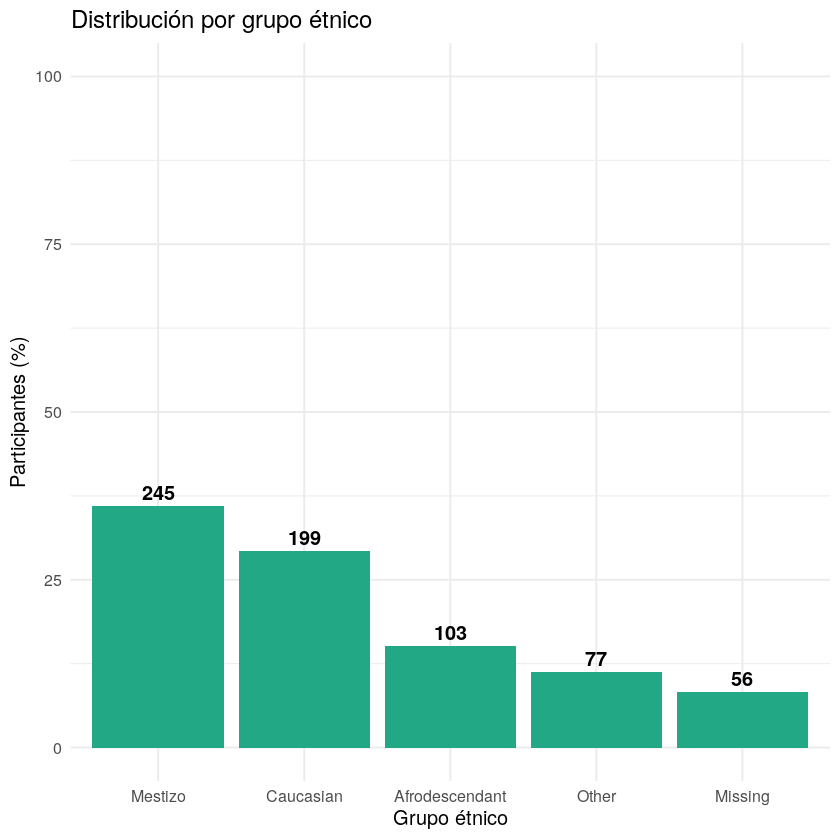

In [17]:
plot_freq(ethnicity_tbl, "Distribución por grupo étnico", "Grupo étnico")

## Nivel socioeconómico (SSE)

Los seis estratos oficiales del DANE fueron colapsados en tres niveles
(`Low`, `Medium`, `High`) para evitar categorías con frecuencias
extremadamente bajas en los estratos superiores.

In [18]:
sse_tbl <- freq_table(df, "SSE", levels_order = c("Low", "Medium", "High"))
sse_tbl %>% gt() %>% tab_header(title = "Nivel socioeconómico")

<div id="bgholschpd" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#bgholschpd table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#bgholschpd thead, #bgholschpd tbody, #bgholschpd tfoot, #bgholschpd tr, #bgholschpd td, #bgholschpd th {
  border-style: none;
}

#bgholschpd p {
  margin: 0;
  padding: 0;
}

#bgholschpd .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#bgholschpd .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#bgholschpd .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#bgholschpd .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#bgholschpd .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#bgholschpd .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#bgholschpd .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#bgholschpd .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#bgholschpd .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#bgholschpd .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#bgholschpd .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#bgholschpd .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#bgholschpd .gt_spanner_row {
  border-bottom-style: hidden;
}

#bgholschpd .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

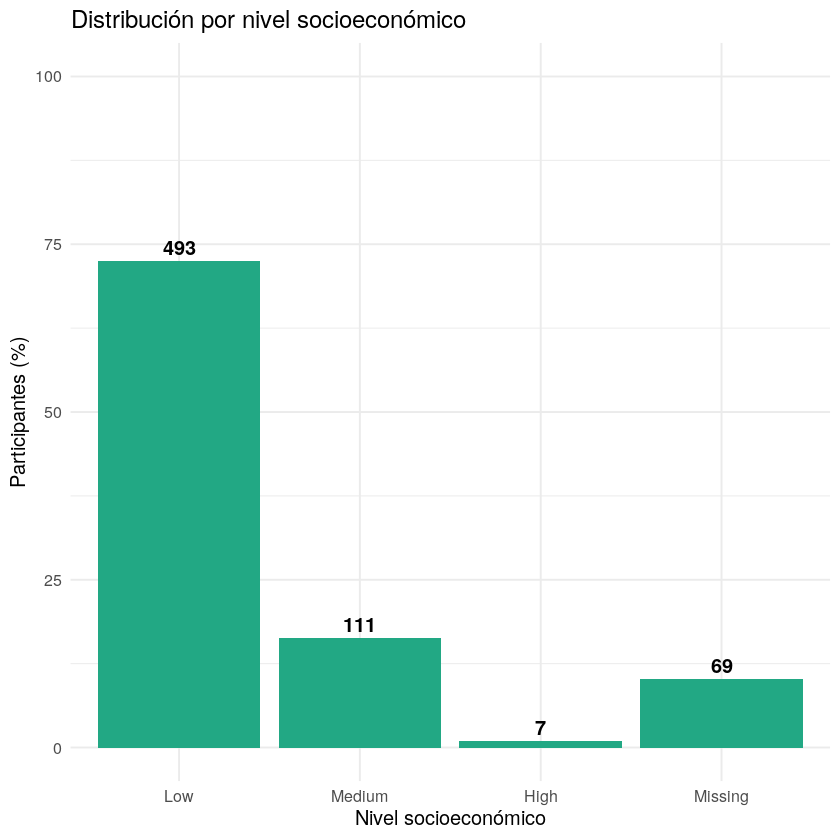

In [19]:
plot_freq(sse_tbl, "Distribución por nivel socioeconómico", "Nivel socioeconómico")

## Nivel educativo de los padres

El nivel educativo más alto alcanzado por los padres o cuidadores fue
colapsado en cuatro categorías: `Primary`, `High School`, `Undergraduate` y
`Graduate`.

In [20]:
education_tbl <- freq_table(df, "Education",
                             levels_order = c("Primary", "High School",
                                               "Undergraduate", "Graduate"))
education_tbl %>% gt() %>% tab_header(title = "Nivel educativo de los padres")

<div id="wuhfpambpm" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#wuhfpambpm table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#wuhfpambpm thead, #wuhfpambpm tbody, #wuhfpambpm tfoot, #wuhfpambpm tr, #wuhfpambpm td, #wuhfpambpm th {
  border-style: none;
}

#wuhfpambpm p {
  margin: 0;
  padding: 0;
}

#wuhfpambpm .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#wuhfpambpm .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#wuhfpambpm .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#wuhfpambpm .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#wuhfpambpm .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#wuhfpambpm .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#wuhfpambpm .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#wuhfpambpm .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#wuhfpambpm .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#wuhfpambpm .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#wuhfpambpm .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#wuhfpambpm .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#wuhfpambpm .gt_spanner_row {
  border-bottom-style: hidden;
}

#wuhfpambpm .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

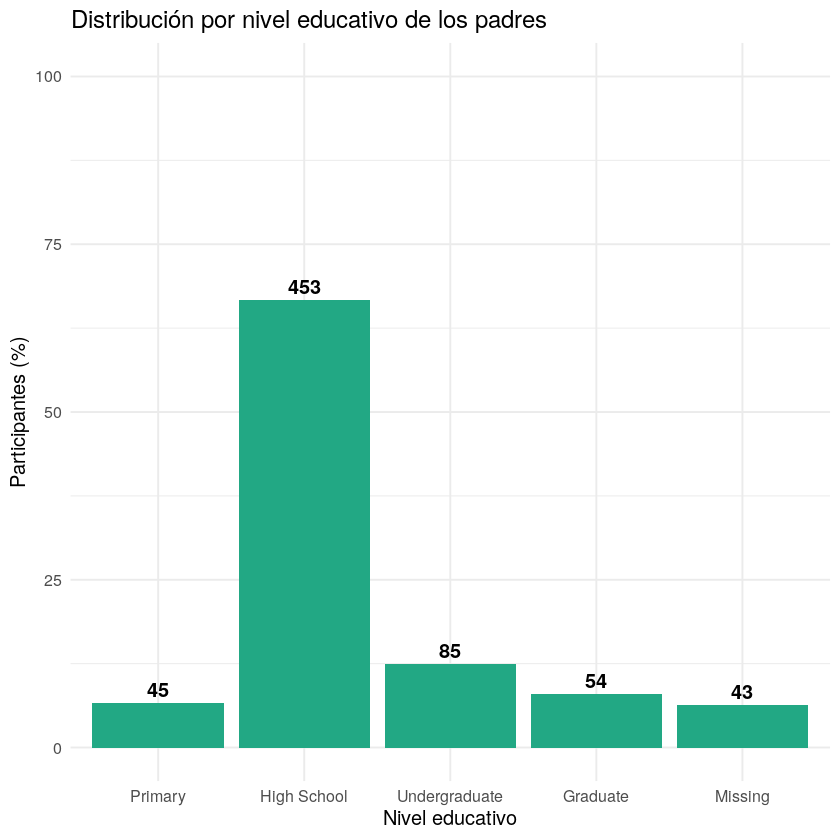

In [21]:
plot_freq(education_tbl, "Distribución por nivel educativo de los padres",
           "Nivel educativo")

## Apoyo social percibido y *entrapment*

Las columnas `Family`, `Friends` y `SigOthers` corresponden a los puntajes
latentes estimados para las tres dimensiones del MSPSS (familia, amigos y
otras personas significativas), y `Entrapment` / `Entrapment_SE` al puntaje
latente de *entrapment* y su error estándar. Estas son las variables
centrales de los modelos de moderación planteados en los objetivos
específicos del proyecto, por lo que se exploran aquí con el mismo nivel de
detalle que las covariables sociodemográficas.

In [22]:
support_vars <- c("Family", "Friends", "SigOthers", "Entrapment", "Entrapment_SE")

support_summary <- df %>%
  select(all_of(support_vars)) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "value") %>%
  group_by(Variable) %>%
  summarise(
    n = sum(!is.na(value)),
    n_missing = sum(is.na(value)),
    mean = round(mean(value, na.rm = TRUE), 3),
    sd = round(sd(value, na.rm = TRUE), 3),
    median = round(median(value, na.rm = TRUE), 3),
    IQR = round(IQR(value, na.rm = TRUE), 3),
    min = round(min(value, na.rm = TRUE), 3),
    max = round(max(value, na.rm = TRUE), 3),
    .groups = "drop"
  )

support_summary %>% gt() %>% tab_header(title = "Resumen: apoyo social y entrapment")

<div id="rsmhutimcq" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#rsmhutimcq table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#rsmhutimcq thead, #rsmhutimcq tbody, #rsmhutimcq tfoot, #rsmhutimcq tr, #rsmhutimcq td, #rsmhutimcq th {
  border-style: none;
}

#rsmhutimcq p {
  margin: 0;
  padding: 0;
}

#rsmhutimcq .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#rsmhutimcq .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#rsmhutimcq .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#rsmhutimcq .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#rsmhutimcq .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#rsmhutimcq .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#rsmhutimcq .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#rsmhutimcq .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#rsmhutimcq .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#rsmhutimcq .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#rsmhutimcq .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#rsmhutimcq .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#rsmhutimcq .gt_spanner_row {
  border-bottom-style: hidden;
}

#rsmhutimcq .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

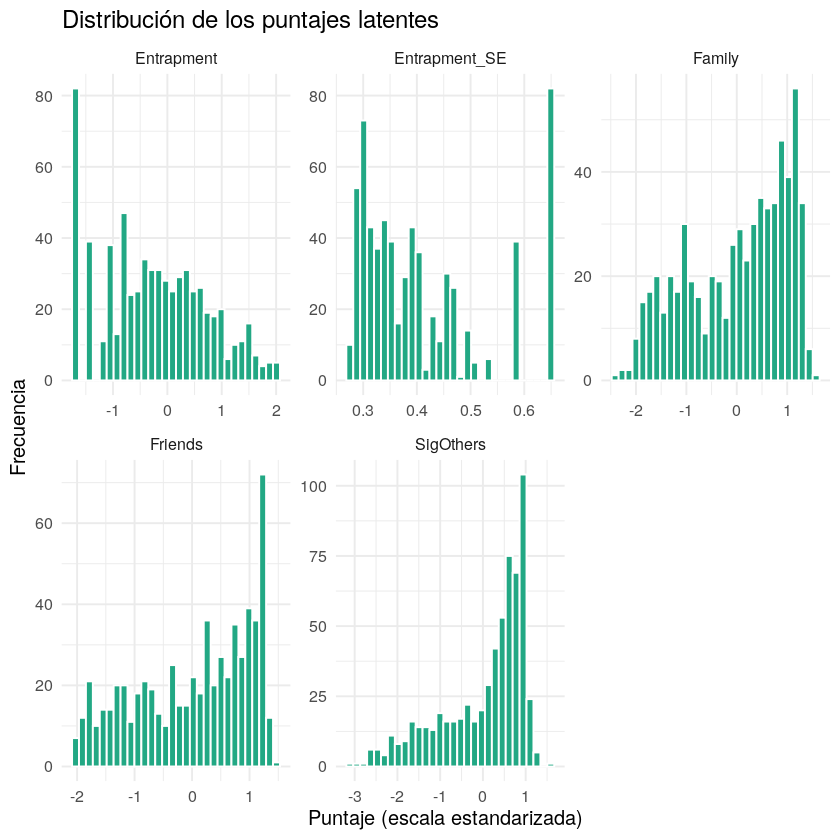

In [23]:
df %>%
  select(all_of(support_vars)) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "value") %>%
  filter(!is.na(value)) %>%
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = bar_fill, color = "white") +
  facet_wrap(~ Variable, scales = "free") +
  labs(title = "Distribución de los puntajes latentes",
       x = "Puntaje (escala estandarizada)", y = "Frecuencia")

### Valores atípicos (filtro de Hampel)

Se aplica el mismo criterio de detección de atípicos usado para las
variables antropométricas en el EDA original, sobre cada uno de los
puntajes latentes.

In [24]:
outlier_counts <- map_dfr(c("Family", "Friends", "SigOthers", "Entrapment"), function(v) {
  bounds <- hampel_bounds(df[[v]])
  n_out <- sum(df[[v]] < bounds["lower"] | df[[v]] > bounds["upper"], na.rm = TRUE)
  tibble(Variable = v, lower = bounds["lower"], upper = bounds["upper"], n_outliers = n_out)
})

outlier_counts %>% gt() %>% tab_header(title = "Límites de Hampel y atípicos")

<div id="qgivbrnrgv" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#qgivbrnrgv table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#qgivbrnrgv thead, #qgivbrnrgv tbody, #qgivbrnrgv tfoot, #qgivbrnrgv tr, #qgivbrnrgv td, #qgivbrnrgv th {
  border-style: none;
}

#qgivbrnrgv p {
  margin: 0;
  padding: 0;
}

#qgivbrnrgv .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#qgivbrnrgv .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#qgivbrnrgv .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#qgivbrnrgv .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#qgivbrnrgv .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#qgivbrnrgv .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#qgivbrnrgv .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#qgivbrnrgv .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#qgivbrnrgv .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#qgivbrnrgv .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#qgivbrnrgv .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#qgivbrnrgv .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#qgivbrnrgv .gt_spanner_row {
  border-bottom-style: hidden;
}

#qgivbrnrgv .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-

### Correlación entre dimensiones de apoyo social y *entrapment*

Como primer acercamiento a la Pregunta clave 1 y 2 del proyecto (si el apoyo
social predice el *entrapment*, y si esto difiere según la fuente de
apoyo), se examina la matriz de correlación entre las tres dimensiones del
MSPSS y el *entrapment*.

In [25]:
cor_mat <- df %>%
  select(Family, Friends, SigOthers, Entrapment) %>%
  cor(use = "pairwise.complete.obs") %>%
  round(3)

cor_mat

,Family,Friends,SigOthers,Entrapment
Family,1.000,0.433,0.521,-0.403
Friends,0.433,1.000,0.556,-0.221
SigOthers,0.521,0.556,1.000,-0.186
Entrapment,-0.403,-0.221,-0.186,1.000


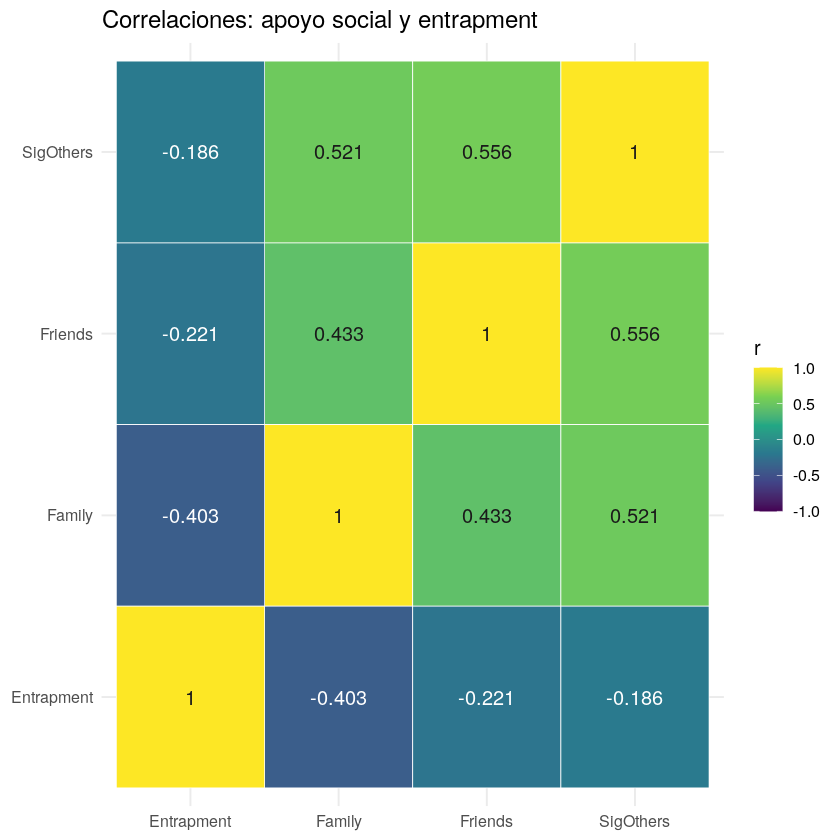

In [26]:
cor_mat %>%
  as.data.frame() %>%
  rownames_to_column("var1") %>%
  pivot_longer(-var1, names_to = "var2", values_to = "r") %>%
  ggplot(aes(x = var1, y = var2, fill = r)) +
  geom_tile(color = "white") +
  geom_text(aes(label = r, color = r > 0.3)) +
  scale_fill_viridis_c(limits = c(-1, 1)) +
  scale_color_manual(values = c(`TRUE` = "grey10", `FALSE` = "white"), guide = "none") +
  labs(title = "Correlaciones: apoyo social y entrapment", x = NULL, y = NULL)

## Apoyo social y *entrapment* por género

Exploración bivariada preliminar de la Pregunta clave 3 (si el género
modera la relación entre apoyo social y *entrapment*). Estos boxplots son
puramente descriptivos; la evaluación formal de la moderación se abordará en
los modelos de regresión jerárquica y de interacción planteados en los
objetivos específicos 2 y 3.

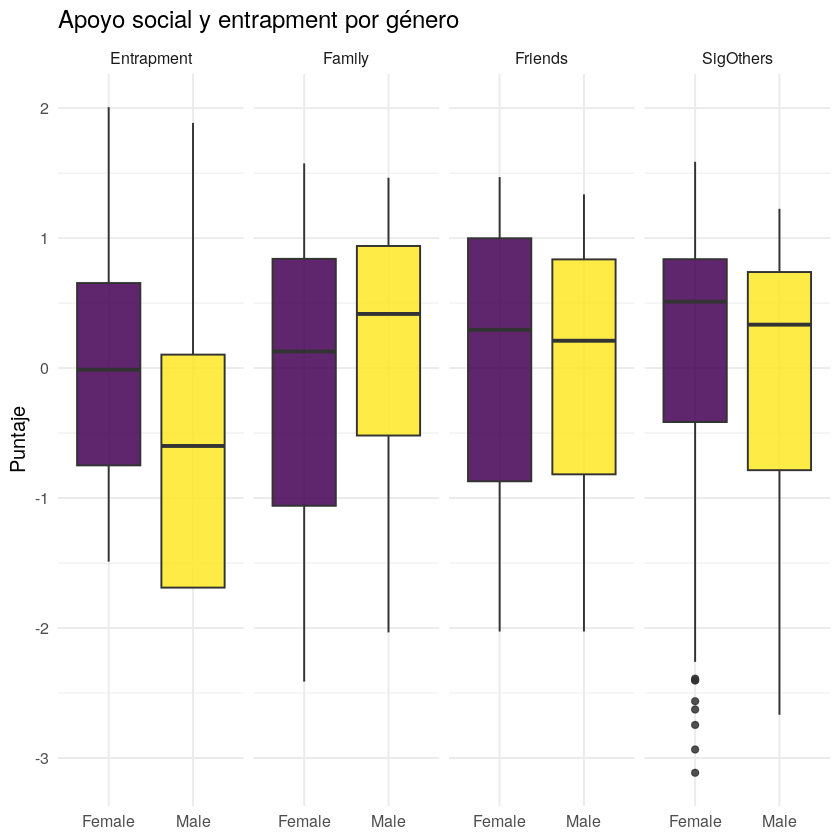

In [27]:
df %>%
  filter(!is.na(Gender)) %>%
  select(Gender, all_of(support_vars[1:4])) %>%
  pivot_longer(-Gender, names_to = "Variable", values_to = "value") %>%
  filter(!is.na(value)) %>%
  ggplot(aes(x = Gender, y = value, fill = Gender)) +
  geom_boxplot(alpha = 0.85, show.legend = FALSE) +
  facet_wrap(~ Variable, nrow = 1) +
  scale_fill_viridis_d() +
  labs(title = "Apoyo social y entrapment por género", x = NULL, y = "Puntaje")

In [28]:
df %>%
  filter(!is.na(Gender)) %>%
  select(Gender, all_of(support_vars[1:4])) %>%
  pivot_longer(-Gender, names_to = "Variable", values_to = "value") %>%
  filter(!is.na(value)) %>%
  group_by(Variable, Gender) %>%
  summarise(mean = round(mean(value), 3), sd = round(sd(value), 3), n = n(), .groups = "drop") %>%
  arrange(Variable, Gender) %>%
  gt() %>%
  tab_header(title = "Medias por género")

<div id="zriswxhpyd" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#zriswxhpyd table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#zriswxhpyd thead, #zriswxhpyd tbody, #zriswxhpyd tfoot, #zriswxhpyd tr, #zriswxhpyd td, #zriswxhpyd th {
  border-style: none;
}

#zriswxhpyd p {
  margin: 0;
  padding: 0;
}

#zriswxhpyd .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  border-right-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #A8A8A8;
  border-left-style: none;
  border-left-width: 2px;
  border-left-color: #D3D3D3;
}

#zriswxhpyd .gt_caption {
  padding-top: 4px;
  padding-bottom: 4px;
}

#zriswxhpyd .gt_title {
  color: #333333;
  font-size: 125%;
  font-weight: initial;
  padding-top: 4px;
  padding-bottom: 4px;
  padding-left: 5px;
  padding-right: 5px;
  border-bottom-color: #FFFFFF;
  border-bottom-width: 0;
}

#zriswxhpyd .gt_subtitle {
  color: #333333;
  font-size: 85%;
  font-weight: initial;
  padding-top: 3px;
  padding-bottom: 5px;
  padding-left: 5px;
  padding-right: 5px;
  border-top-color: #FFFFFF;
  border-top-width: 0;
}

#zriswxhpyd .gt_heading {
  background-color: #FFFFFF;
  text-align: center;
  border-bottom-color: #FFFFFF;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#zriswxhpyd .gt_bottom_border {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
}

#zriswxhpyd .gt_col_headings {
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
}

#zriswxhpyd .gt_col_heading {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  border-left-style: none;
  border-left-width: 1px;
  border-left-color: #D3D3D3;
  border-right-style: none;
  border-right-width: 1px;
  border-right-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 6px;
  padding-left: 5px;
  padding-right: 5px;
  overflow-x: hidden;
}

#zriswxhpyd .gt_column_spanner_outer {
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: normal;
  text-transform: inherit;
  padding-top: 0;
  padding-bottom: 0;
  padding-left: 4px;
  padding-right: 4px;
}

#zriswxhpyd .gt_column_spanner_outer:first-child {
  padding-left: 0;
}

#zriswxhpyd .gt_column_spanner_outer:last-child {
  padding-right: 0;
}

#zriswxhpyd .gt_column_spanner {
  border-bottom-style: solid;
  border-bottom-width: 2px;
  border-bottom-color: #D3D3D3;
  vertical-align: bottom;
  padding-top: 5px;
  padding-bottom: 5px;
  overflow-x: hidden;
  display: inline-block;
  width: 100%;
}

#zriswxhpyd .gt_spanner_row {
  border-bottom-style: hidden;
}

#zriswxhpyd .gt_group_heading {
  padding-top: 8px;
  padding-bottom: 8px;
  padding-left: 5px;
  padding-right: 5px;
  color: #333333;
  background-color: #FFFFFF;
  font-size: 100%;
  font-weight: initial;
  text-transform: inherit;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #D3D3D3;
  border-